# LCoTTA Adaptation on Messidor-2 (VisionFM)
LCoTTA: entropy minimization on norm layers with updates projected onto an online-tracked low-dimensional gradient subspace.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/lcotta/messidor2_visionfm.yaml')

print('Dataset:', config.target_dataset.name)
print('Method:', config.ctta.method)
print('Mode: every-batch (no shift detection gate)')
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Dataset: messidor2
Method: lcotta
Mode: every-batch (no shift detection gate)
Output: ./outputs/lcotta/messidor2_visionfm/
No HF token needed (VisionFM / Google Drive)


In [4]:
from src.evaluation.runner import CTTARunner

runner = CTTARunner(config)
results = runner.run()

2026-08-23 09:16:53,549 - src.evaluation.runner.single - INFO - Starting CTTA adaptation on dataset: messidor2
2026-08-23 09:16:53,550 - src.models.visionfm_download - INFO - VisionFM Fundus weights found at ./cache/visionfm/VFM_Fundus_weights.pth (cached)
2026-08-23 09:16:54,696 - src.models.visionfm - INFO - Loading VisionFM checkpoint from /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
2026-08-23 09:16:56,340 - src.models.visionfm - INFO - Extracted state_dict from 'teacher' key
2026-08-23 09:16:56,343 - src.models.visionfm - INFO - Stripped 'backbone.' prefix from 160 state dict keys
2026-08-23 09:16:56,413 - src.models.visionfm - INFO - VisionFM checkpoint cached in CPU RAM
2026-08-23 09:16:56,450 - src.models.visionfm - INFO - Frozen first 8 of 12 transformer blocks
2026-08-23 09:16:56,451 - src.models.visionfm - INFO - Feature normalization ENABLED in forward()
2026-08-23 09:16:56,887 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
20

Adapting to messidor2:   0%|          | 0/22 [00:00<?, ?it/s]

2026-08-23 09:17:28,904 - src.evaluation.runner.single - INFO -   Adapt step 0: loss=0.4248, entropy=0.8823, conf_samples=6, queue=0, subspace=off, proj_ratio=-1.000


Adapting to messidor2:   5%|▍         | 1/22 [00:01<00:31,  1.51s/it, acc=0.3750, adaptations=1]

2026-08-23 09:17:29,931 - src.evaluation.runner.single - INFO -   Adapt step 1: loss=0.5070, entropy=0.9458, conf_samples=4, queue=1, subspace=off, proj_ratio=-1.000


...

Adapting to messidor2:  95%|█████████▌| 21/22 [00:21<00:00,  1.01it/s, acc=0.4375, adaptations=21]

2026-08-23 09:17:50,099 - src.evaluation.runner.single - INFO -   Adapt step 21: loss=0.3531, entropy=0.7863, conf_samples=4, queue=14, subspace=on, proj_ratio=0.972


Adapting to messidor2: 100%|██████████| 22/22 [00:22<00:00,  1.03s/it, acc=0.5385, adaptations=22]

2026-08-23 09:17:50,296 - src.evaluation.runner.single - INFO - Evaluating after adaptation on messidor2


2026-08-23 09:17:55,902 - src.evaluation.runner.single - INFO - Post-adaptation QWK: 0.4917
2026-08-23 09:17:55,904 - src.evaluation.runner.single - INFO - Adaptations: 22/22
2026-08-23 09:17:55,939 - src.evaluation.runner.base - INFO - Results saved to outputs/lcotta/messidor2_visionfm/ctta_results.json


In [5]:
print('=== Results ===')
print(f'Baseline QWK:        {results["baseline_metrics"]["qwk"]:.4f}')
print(f'Baseline Accuracy:   {results["baseline_metrics"]["overall_accuracy"]*100:.2f}%')
print(f'Post-adapt QWK:      {results["final_metrics"]["qwk"]:.4f}')
print(f'Post-adapt Accuracy: {results["final_metrics"]["overall_accuracy"]*100:.2f}%')
dr = results['domain_result']
print(f'Adaptations:          {dr["num_adaptations"]}/{dr["total_batches"]}')
print(f'Adaptation rate:      {results.get("adaptation_rate", 0)*100:.2f}%')

gap = results['final_metrics']['qwk'] - results['baseline_metrics']['qwk']
print(f'QWK change:           {gap:+.4f}')
acc_gap = results['final_metrics']['overall_accuracy'] - results['baseline_metrics']['overall_accuracy']
print(f'Accuracy change:      {acc_gap*100:+.2f}%')

=== Results ===
Baseline QWK:        0.5021
Baseline Accuracy:   54.73%
Post-adapt QWK:      0.4917
Post-adapt Accuracy: 55.30%
Adaptations:          22/22
Adaptation rate:      100.00%
QWK change:           -0.0104
Accuracy change:      +0.57%


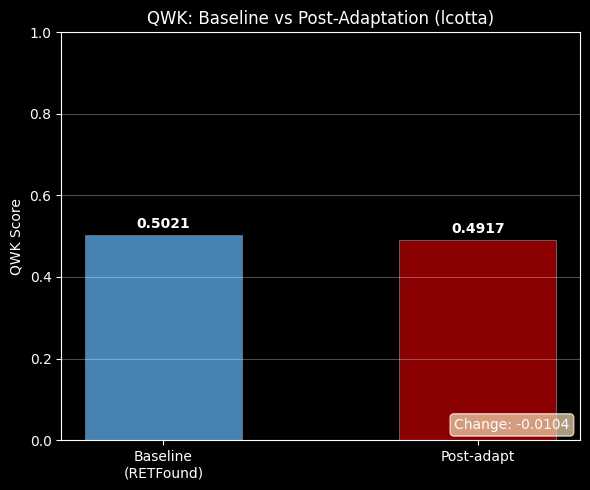

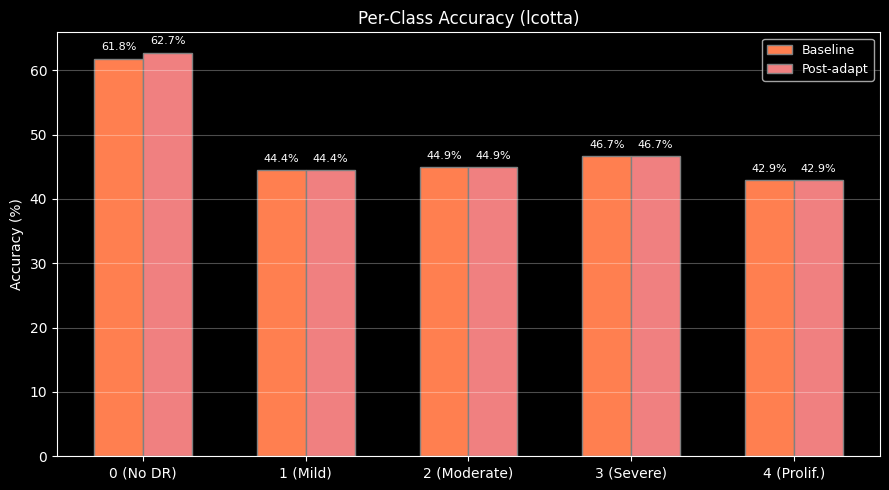

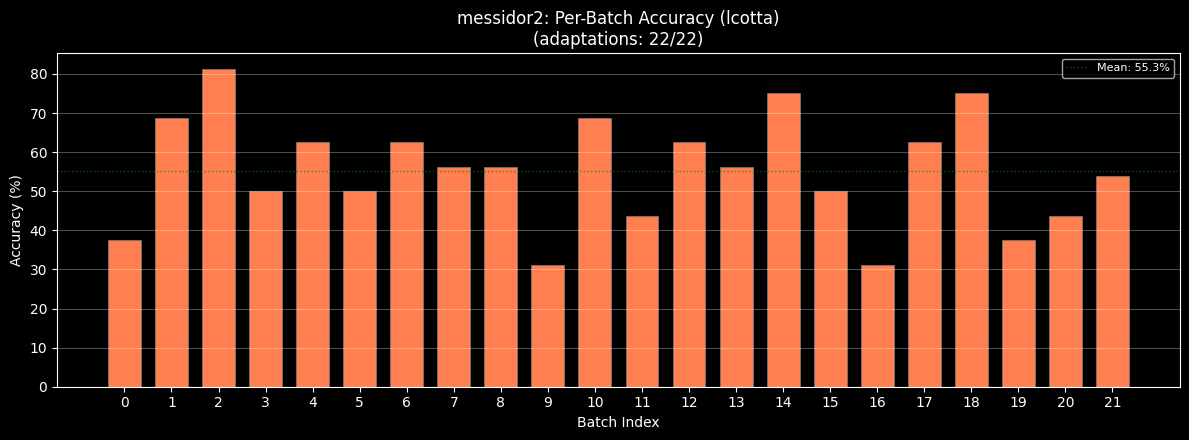

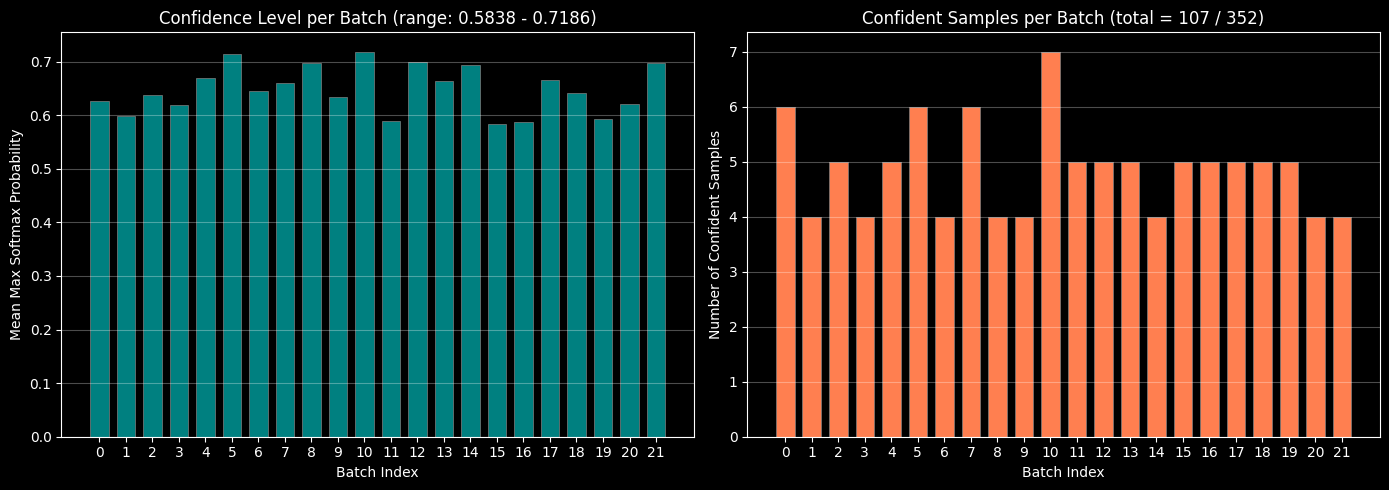

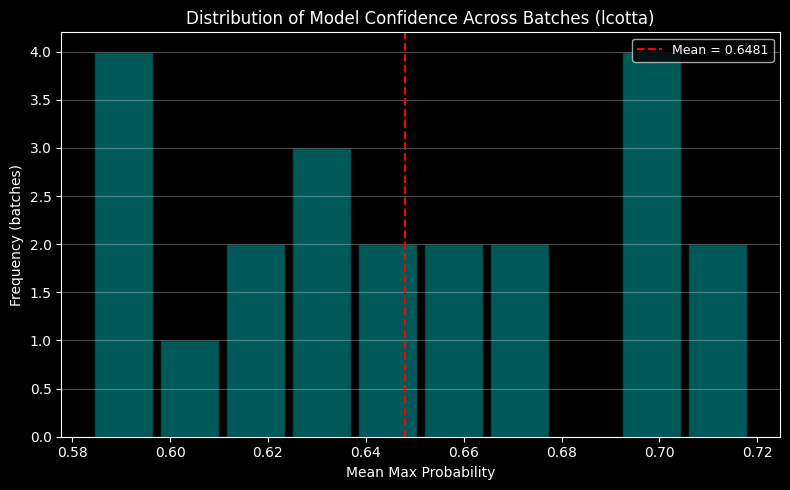

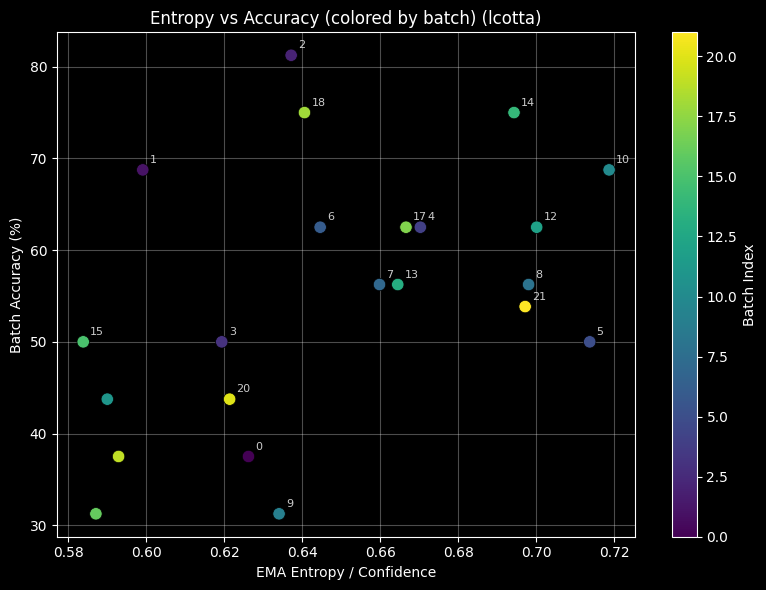

===================== CTTA Results (lcotta) =====================
Baseline QWK:       0.5021
Post-adapt QWK:     0.4917
Adaptations:        22/22
Adaptation rate:    100.00%
QWK change:         -0.0104
Mean batch acc:     55.3%


In [6]:
from src.viz import (
    plot_qwk_bar, plot_per_batch_accuracy,
    plot_adaptation_metrics, plot_confidence_distribution,
    plot_entropy_vs_accuracy, print_summary_table, plot_per_class_accuracy as plot_pca,
)

import json
from pathlib import Path

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

with open(Path(config.output_dir) / 'ctta_results.json') as f:
    results = json.load(f)

dr = results['domain_result']
method = results.get("method", "")

plot_qwk_bar(results, plots_dir, method_name=method)
plot_pca(results, dr, plots_dir, method_name=method)
plot_per_batch_accuracy(dr, None, plots_dir, method_name=method)
plot_adaptation_metrics(dr['adaptation_steps'], plots_dir)
plot_confidence_distribution(dr['adaptation_steps'], plots_dir, method_name=method)
plot_entropy_vs_accuracy(dr['adaptation_steps'], dr['batch_metrics'], plots_dir, method_name=method)
print_summary_table(results, method_name=method)